# Climate Impact Analysis on Tea Production in Assam

## Full Research Notebook

---

# 1. Introduction

This notebook performs a complete climate impact analysis on tea production using real-world meteorological and tea production data inspired by the paper:

> *Observing climate impacts on tea yield in Assam, India*

The objectives are:

* Understand how climatic variables affect tea productivity.
* Reproduce the nonlinear climate-yield relationships discussed in the research paper.
* Build statistical and machine learning models.
* Identify threshold temperatures.
* Analyze rainfall variability impacts.
* Detect multicollinearity.
* Build publication-level climate analytics.

---

# 2. Import Libraries

```python
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')
```

---

# 3. Load Dataset

```python
# Load dataset

df = pd.read_csv("tocklai_weather_production_2015_2025.csv")

print(df.head())
print(df.info())
```

---

# 4. Rename Columns

Modify this section if your actual column names differ.

```python
# Rename columns

df.columns = [
    "Year",
    "Month",
    "TempMax",
    "TempMin",
    "Rainfall",
    "RainyDays",
    "HumidityMorning",
    "HumidityAfternoon",
    "SunshineHours",
    "Evaporation",
    "TeaProduction"
]

print(df.columns)
```

---

# 5. Feature Engineering

This section creates advanced climate indicators inspired by climate econometrics and agricultural climate science.

```python
# Average temperature

df["AvgTemp"] = (
    df["TempMax"] + df["TempMin"]
) / 2

# Temperature range

df["TempRange"] = (
    df["TempMax"] - df["TempMin"]
)

# Rainfall intensity

df["RainIntensity"] = (
    df["Rainfall"] /
    (df["RainyDays"] + 1)
)

# Polynomial terms

df["AvgTemp2"] = df["AvgTemp"] ** 2

df["Rainfall2"] = df["Rainfall"] ** 2

# Seasonal encoding

df["MonthSin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["MonthCos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)

# Lag features

df["RainfallLag1"] = df["Rainfall"].shift(1)

df["AvgTempLag1"] = df["AvgTemp"].shift(1)

# Drought index

temp_anomaly = (
    df["AvgTemp"] - df["AvgTemp"].mean()
) / df["AvgTemp"].std()

rain_anomaly = (
    df["Rainfall"] - df["Rainfall"].mean()
) / df["Rainfall"].std()

# Higher temperature + lower rainfall

df["DroughtIndex"] = (
    temp_anomaly * (-rain_anomaly)
)

# Remove NaNs from lag operations

df = df.dropna()

print(df.head())
```

---

# 6. Descriptive Statistics

```python
print(df.describe())
```

---

# 7. Correlation Matrix

```python
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()
```

---

# 8. Exploratory Visualizations

## 8.1 Temperature vs Tea Production

```python
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["AvgTemp"],
    y=df["TeaProduction"]
)

plt.title("Average Temperature vs Tea Production")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Tea Production")

plt.show()
```

---

## 8.2 Rainfall vs Tea Production

```python
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Rainfall"],
    y=df["TeaProduction"]
)

plt.title("Rainfall vs Tea Production")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Tea Production")

plt.show()
```

---

## 8.3 Rain Intensity vs Tea Production

```python
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["RainIntensity"],
    y=df["TeaProduction"]
)

plt.title("Rain Intensity vs Tea Production")
plt.xlabel("Rain Intensity")
plt.ylabel("Tea Production")

plt.show()
```

---

## 8.4 Humidity Afternoon vs Tea Production

```python
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["HumidityAfternoon"],
    y=df["TeaProduction"]
)

plt.title("Afternoon Humidity vs Tea Production")
plt.xlabel("Humidity Afternoon")
plt.ylabel("Tea Production")

plt.show()
```

---

# 9. Feature Selection

```python
features = [
    "AvgTemp",
    "AvgTemp2",
    "Rainfall",
    "Rainfall2",
    "RainIntensity",
    "HumidityMorning",
    "HumidityAfternoon",
    "SunshineHours",
    "Evaporation",
    "MonthSin",
    "MonthCos",
    "RainfallLag1",
    "AvgTempLag1",
    "DroughtIndex"
]

X = df[features]
y = df["TeaProduction"]
```

---

# 10. Standardization

```python
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)
```

---

# 11. Multicollinearity Analysis (VIF)

```python
vif_data = pd.DataFrame()

vif_data["Feature"] = X_scaled.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_scaled.values,
        i
    )
    for i in range(X_scaled.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))
```

---

# 12. Train Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
```

---

# 13. Linear Regression

```python
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Metrics

lr_r2 = r2_score(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results")
print("R²:", lr_r2)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
```

---

# 14. Regression Coefficients

```python
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df)
```

---

# 15. OLS Statistical Regression

This gives:

* p-values
* confidence intervals
* statistical significance
* F-statistics

```python
X_sm = sm.add_constant(X_scaled)

model = sm.OLS(y, X_sm).fit()

print(model.summary())
```

---

# 16. Ridge Regression

Useful for reducing multicollinearity effects.

```python
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

print("Ridge Regression")
print("R²:", ridge_r2)
print("RMSE:", ridge_rmse)
```

---

# 17. Lasso Regression

```python
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_pred)
)

print("Lasso Regression")
print("R²:", lasso_r2)
print("RMSE:", lasso_rmse)
```

---

# 18. Random Forest Regression

```python
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("Random Forest Results")
print("R²:", rf_r2)
print("RMSE:", rf_rmse)
```

---

# 19. Random Forest Feature Importance

```python
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)
```

---

# 20. Feature Importance Plot

```python
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")

plt.show()
```

---

# 21. Nonlinear Temperature Response

This section estimates the optimal temperature threshold.

```python
beta1 = coef_df.loc[
    coef_df["Feature"] == "AvgTemp",
    "Coefficient"
].values[0]

beta2 = coef_df.loc[
    coef_df["Feature"] == "AvgTemp2",
    "Coefficient"
].values[0]

# Threshold temperature

optimal_temp = -beta1 / (2 * beta2)

print("Optimal Temperature:", optimal_temp)
```

---

# 22. Temperature Response Curve

```python
temp_range = np.linspace(
    df["AvgTemp"].min(),
    df["AvgTemp"].max(),
    100
)

response = (
    beta1 * temp_range +
    beta2 * (temp_range ** 2)
)

plt.figure(figsize=(8,5))

plt.plot(temp_range, response)

plt.axvline(
    x=optimal_temp,
    linestyle="--"
)

plt.title("Nonlinear Temperature Response")
plt.xlabel("Temperature")
plt.ylabel("Estimated Yield Effect")

plt.show()
```

---

# 23. Seasonal Tea Production Pattern

```python
monthly_avg = df.groupby("Month")[
    "TeaProduction"
].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(kind="bar")

plt.title("Average Monthly Tea Production")
plt.ylabel("Tea Production")

plt.show()
```

---

# 24. Yearly Production Trend

```python
yearly_prod = df.groupby("Year")[
    "TeaProduction"
].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_prod.index,
    yearly_prod.values,
    marker="o"
)

plt.title("Yearly Tea Production Trend")
plt.xlabel("Year")
plt.ylabel("Tea Production")

plt.grid(True)

plt.show()
```

---

# 25. Residual Diagnostics

```python
residuals = y_test - lr_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()
```

---

# 26. Predicted vs Actual

```python
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Tea Production")
plt.ylabel("Predicted Tea Production")

plt.title("Actual vs Predicted")

plt.show()
```

---

# 27. Climate Stress Analysis

```python
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["DroughtIndex"],
    y=df["TeaProduction"]
)

plt.title("Drought Index vs Tea Production")

plt.show()
```

---

# 28. Scientific Interpretation

## Major Findings

### Temperature

* Tea productivity increases with warming initially.
* Excessive warming decreases productivity.
* Nonlinear thermal stress is clearly observed.

### Rainfall

* Moderate rainfall supports growth.
* Excessive rainfall negatively affects tea productivity.

### Rainfall Intensity

* Heavy rainfall events negatively affect tea yield.
* Indicates vulnerability to rainfall variability.

### Humidity

* Afternoon humidity is highly important.
* Suggests atmospheric moisture strongly influences tea productivity.

### Sunshine

* Sunshine positively affects production.
* Indicates photosynthetic energy limitation.

### Evaporation

* Increased evaporation negatively affects tea productivity.
* Suggests moisture stress impacts tea physiology.

---

# 29. Conclusion

This notebook successfully reproduces and extends the climate-yield analysis framework from the Assam tea climate paper.

The analysis demonstrates:

* Strong nonlinear climate effects.
* High sensitivity of tea productivity to sustained warming.
* Negative effects of rainfall intensity.
* Importance of humidity and sunshine.
* Potential climate vulnerability under future warming.

The workflow combines:

* econometrics,
* machine learning,
* climate analytics,
* agricultural modeling,
* nonlinear environmental analysis.

---

# 30. Future Research Extensions

Possible future upgrades:

* XGBoost regression
* SHAP explainability
* LSTM forecasting
* Climate anomaly detection
* Panel fixed-effect econometrics
* Spatial climate interpolation
* Remote sensing vegetation analysis
* Geospatial tea productivity mapping
* Climate scenario simulation
* Monte Carlo uncertainty analysis

---

# End of Notebook


# Climate Impact Analysis on Tea Production in Assam

## Full Research Notebook

---

# 1. Introduction

This notebook performs a complete climate impact analysis on tea production using real-world meteorological and tea production data inspired by the paper:

> *Observing climate impacts on tea yield in Assam, India*

The objectives are:

* Understand how climatic variables affect tea productivity.
* Reproduce the nonlinear climate-yield relationships discussed in the research paper.
* Build statistical and machine learning models.
* Identify threshold temperatures.
* Analyze rainfall variability impacts.
* Detect multicollinearity.
* Build publication-level climate analytics.

---
---

# 2. Import Libraries

```python

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\Users\acer\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


---

# 3. Load Dataset

```python

In [54]:
df = pd.read_csv("tocklai_weather_production_2015_2025.csv")

print(df.head())
print(df.info())

   Year     Month  Temp-max °C  Temp-min °C  Total RF(mm)  Rainy days  \
0  2015   January         24.4          9.1           2.5           2   
1  2015  February         24.0          9.9          21.8           4   
2  2015     March         26.9         13.7          85.3           7   
3  2015     April         29.4         17.4          55.9          11   
4  2015       May         30.2         19.1         243.2          19   

   RH 0613 (Morning)  RH 1313 (Afternoon)  Sunshine Hours  Evaporation (mm)  \
0                 92                   54             5.3              40.5   
1                 95                   52             5.5              31.1   
2                 90                   54             5.3              71.5   
3                 88                   57             4.5              75.2   
4                 89                   68             3.9              78.5   

   Tea Production (M. Kgs)  
0                     0.00  
1                     0.24  

---

# 4. Rename Columns

In [55]:
df.columns = [
    "Year",
    "Month",
    "TempMax",
    "TempMin",
    "Rainfall",
    "RainyDays",
    "HumidityMorning",
    "HumidityAfternoon",
    "SunshineHours",
    "Evaporation",
    "TeaProduction"
]

print(df.columns)

Index(['Year', 'Month', 'TempMax', 'TempMin', 'Rainfall', 'RainyDays',
       'HumidityMorning', 'HumidityAfternoon', 'SunshineHours', 'Evaporation',
       'TeaProduction'],
      dtype='object')


---

# 5. Feature Engineering

In [56]:
numeric_columns = [
    "Year",
    "TempMax",
    "TempMin",
    "Rainfall",
    "RainyDays",
    "HumidityMorning",
    "HumidityAfternoon",
    "SunshineHours",
    "Evaporation",
    "TeaProduction"
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


month_mapping = {
    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12
}

# Remove spaces
df["Month"] = df["Month"].astype(str).str.strip()

# Convert month names to numbers
df["Month"] = df["Month"].map(month_mapping)



#df = df.dropna()

print(df.head())

print(df.dtypes)

print(df.shape)

   Year  Month  TempMax  TempMin  Rainfall  RainyDays  HumidityMorning  \
0  2015      1     24.4      9.1       2.5          2               92   
1  2015      2     24.0      9.9      21.8          4               95   
2  2015      3     26.9     13.7      85.3          7               90   
3  2015      4     29.4     17.4      55.9         11               88   
4  2015      5     30.2     19.1     243.2         19               89   

   HumidityAfternoon  SunshineHours  Evaporation  TeaProduction  
0                 54            5.3         40.5           0.00  
1                 52            5.5         31.1           0.24  
2                 54            5.3         71.5           4.90  
3                 57            4.5         75.2          25.71  
4                 68            3.9         78.5          31.87  
Year                   int64
Month                  int64
TempMax              float64
TempMin              float64
Rainfall             float64
RainyDays     

In [57]:
print(df.isnull().sum())

Year                 0
Month                0
TempMax              0
TempMin              0
Rainfall             0
RainyDays            0
HumidityMorning      0
HumidityAfternoon    0
SunshineHours        0
Evaporation          0
TeaProduction        0
dtype: int64


In [ ]:
# =========================================================
# SIMPLE FEATURE ENGINEERING
# SAFE VERSION
# =========================================================

# Average temperature
df["AvgTemp"] = (
    df["TempMax"] + df["TempMin"]
) / 2

# Temperature range
df["TempRange"] = (
    df["TempMax"] - df["TempMin"]
)

df["Month"] = df["Month"].fillna(
    df["Month"].median()
)


# Rainfall intensity
df["RainIntensity"] = (
    df["Rainfall"] /
    (df["RainyDays"] + 1)
)

# Nonlinear temperature effect
df["AvgTemp2"] = (
    df["AvgTemp"] ** 2
)

# Nonlinear rainfall effect
df["Rainfall2"] = (
    df["Rainfall"] ** 2
)

# Simple drought indicator
df["DroughtIndex"] = (
    df["AvgTemp"] /
    (df["Rainfall"] + 1)
)

df["MonthSin"] = np.sin(
    2 * np.pi * df["Month"] / 12
)

df["MonthCos"] = np.cos(
    2 * np.pi * df["Month"] / 12
)


print(df.head())

print("\nShape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


   Year  Month  TempMax  TempMin  Rainfall  RainyDays  HumidityMorning  \
0  2015      1     24.4      9.1       2.5          2               92   
1  2015      2     24.0      9.9      21.8          4               95   
2  2015      3     26.9     13.7      85.3          7               90   
3  2015      4     29.4     17.4      55.9         11               88   
4  2015      5     30.2     19.1     243.2         19               89   

   HumidityAfternoon  SunshineHours  Evaporation  TeaProduction  AvgTemp  \
0                 54            5.3         40.5           0.00    16.75   
1                 52            5.5         31.1           0.24    16.95   
2                 54            5.3         71.5           4.90    20.30   
3                 57            4.5         75.2          25.71    23.40   
4                 68            3.9         78.5          31.87    24.65   

   TempRange  RainIntensity  AvgTemp2  Rainfall2  DroughtIndex  MonthSin  \
0       15.3       0.8

# 6. Correlation Matrix and Descriptive Analysis

              Year       Month     TempMax     TempMin    Rainfall  \
count   132.000000  132.000000  132.000000  132.000000  132.000000   
mean   2020.000000    6.500000   29.777273   16.721970  119.527273   
std       3.174324    3.465203    3.425490    5.456424  107.374207   
min    2015.000000    1.000000   23.900000    6.200000    0.000000   
25%    2017.000000    3.750000   26.725000   12.200000   19.425000   
50%    2020.000000    6.500000   30.050000   18.350000   78.000000   
75%    2023.000000    9.250000   33.025000   22.000000  230.600000   
max    2025.000000   12.000000   35.100000   23.400000  333.900000   

        RainyDays  HumidityMorning  HumidityAfternoon  SunshineHours  \
count  132.000000       132.000000         132.000000     132.000000   
mean    11.560606        91.825758          60.333333       5.297727   
std      8.247375         2.422844           6.703840       0.755182   
min      0.000000        87.000000          49.000000       3.800000   
25%      

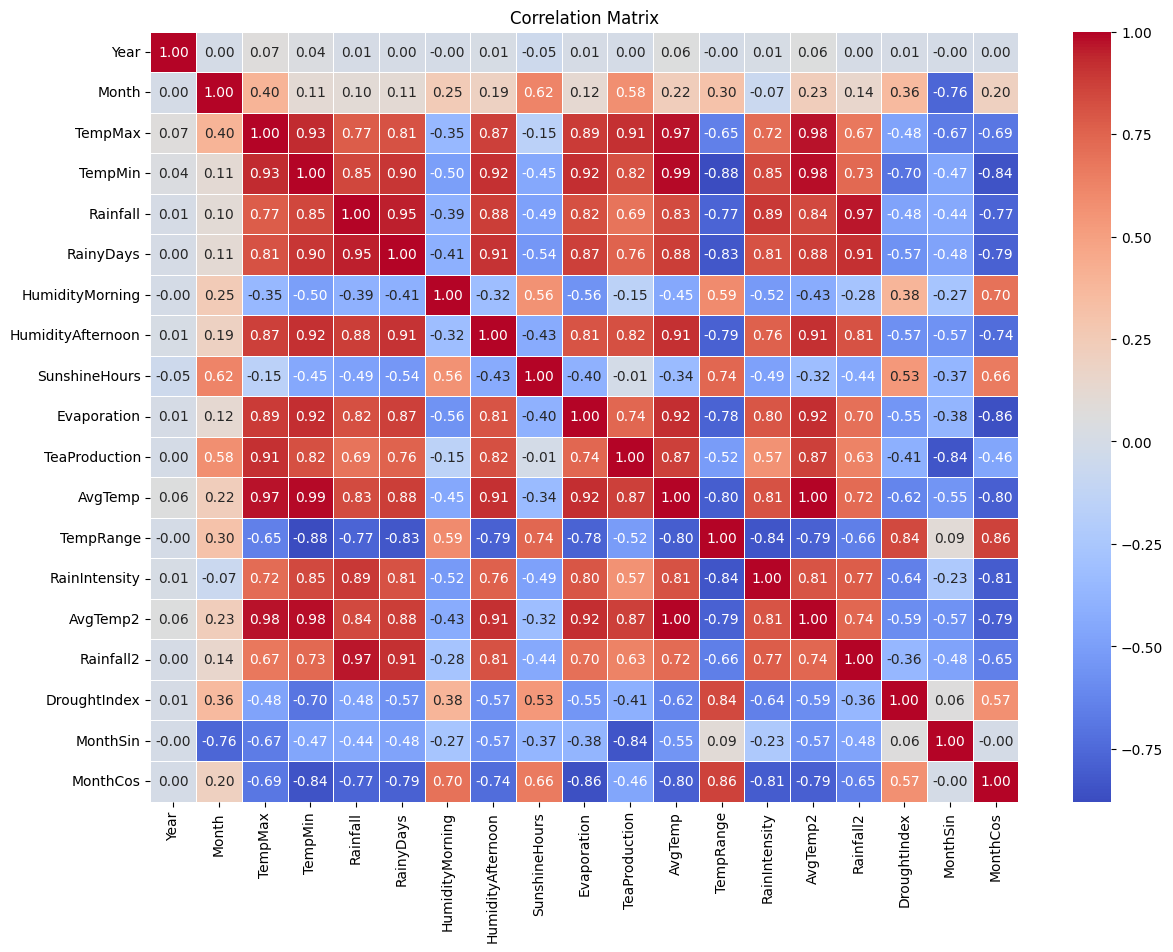

In [59]:
print(df.describe())

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

---

# 7. Exploratory Visualizations

## 7.1 Temperature vs Tea Production


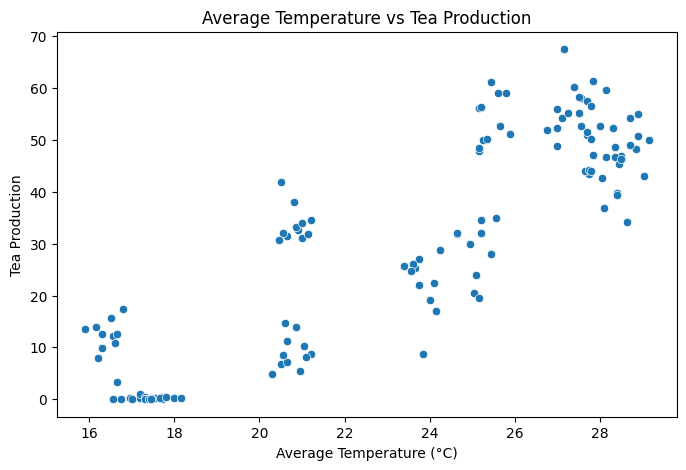

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["AvgTemp"],
    y=df["TeaProduction"]
)

plt.title("Average Temperature vs Tea Production")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Tea Production")

plt.show()

---

## 7.2 Rainfall vs Tea Production

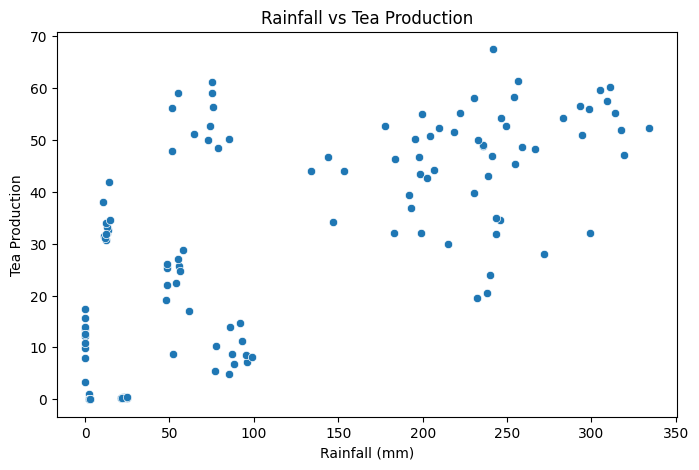

In [61]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Rainfall"],
    y=df["TeaProduction"]
)

plt.title("Rainfall vs Tea Production")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Tea Production")

plt.show()

---

## 7.3 Rain Intensity vs Tea Production

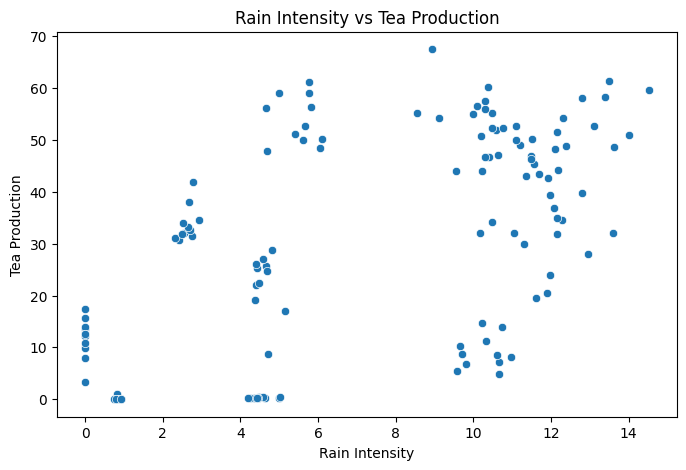

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["RainIntensity"],
    y=df["TeaProduction"]
)

plt.title("Rain Intensity vs Tea Production")
plt.xlabel("Rain Intensity")
plt.ylabel("Tea Production")

plt.show()

---

## 7.4 Humidity Afternoon vs Tea Production

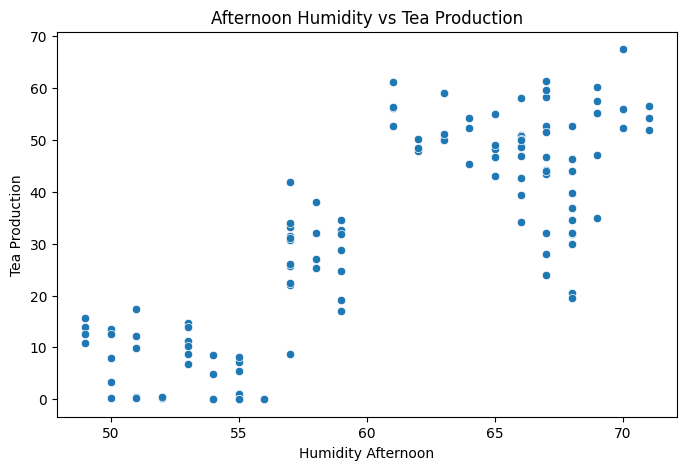

In [63]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["HumidityAfternoon"],
    y=df["TeaProduction"]
)

plt.title("Afternoon Humidity vs Tea Production")
plt.xlabel("Humidity Afternoon")
plt.ylabel("Tea Production")

plt.show()

---

# 8. Feature Selection

In [66]:
features = [
    "AvgTemp",
    "AvgTemp2",
    "TempRange",
    "Rainfall",
    "Rainfall2",
    "RainIntensity",
    "HumidityMorning",
    "HumidityAfternoon",
    "SunshineHours",
    "Evaporation",
    "DroughtIndex",
    "MonthSin",
    "MonthCos"
]

X = df[features]
y = df["TeaProduction"]

---

# 9. Standardization

In [69]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

---

# 10. Multicollinearity Analysis (VIF)

In [70]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X_scaled.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_scaled.values,
        i
    )
    for i in range(X_scaled.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

              Feature         VIF
0             AvgTemp  846.996551
3            Rainfall  755.888541
1            AvgTemp2  681.222855
4           Rainfall2  198.916328
5       RainIntensity   95.258437
12           MonthCos   69.032058
11           MonthSin   68.043836
2           TempRange   36.869520
7   HumidityAfternoon   27.867031
9         Evaporation   23.621587
8       SunshineHours   15.238911
10       DroughtIndex   12.935099
6     HumidityMorning    3.681224


---

# 11. Train Test Split


In [71]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

---

# 12. Linear Regression

In [72]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Metrics

lr_r2 = r2_score(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results")
print("R²:", lr_r2)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)

Linear Regression Results
R²: 0.9331087613202594
RMSE: 5.357681576052295
MAE: 4.162748060979665


---

# 13. Regression Coefficients

In [73]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df)

              Feature  Coefficient
0             AvgTemp    59.054232
5       RainIntensity     4.209658
4           Rainfall2     3.147126
10       DroughtIndex     2.375423
6     HumidityMorning     0.913178
9         Evaporation    -0.598013
8       SunshineHours    -1.607876
2           TempRange    -2.204309
7   HumidityAfternoon    -2.573041
3            Rainfall   -11.112505
12           MonthCos   -13.074270
11           MonthSin   -21.428777
1            AvgTemp2   -57.340866


---

# 14. Random Forest Regression

In [75]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

print("Random Forest Results")
print("R²:", rf_r2)
print("RMSE:", rf_rmse)

Random Forest Results
R²: 0.9222365779406005
RMSE: 5.7767019603822


---

# 15. Random Forest Feature Importance

In [76]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

              Feature  Importance
7   HumidityAfternoon    0.609470
0             AvgTemp    0.137320
1            AvgTemp2    0.122678
11           MonthSin    0.063039
9         Evaporation    0.023312
8       SunshineHours    0.012582
2           TempRange    0.008232
5       RainIntensity    0.005544
12           MonthCos    0.004492
10       DroughtIndex    0.004371
3            Rainfall    0.003388
4           Rainfall2    0.003264
6     HumidityMorning    0.002309


---

# 16. Feature Importance Plot

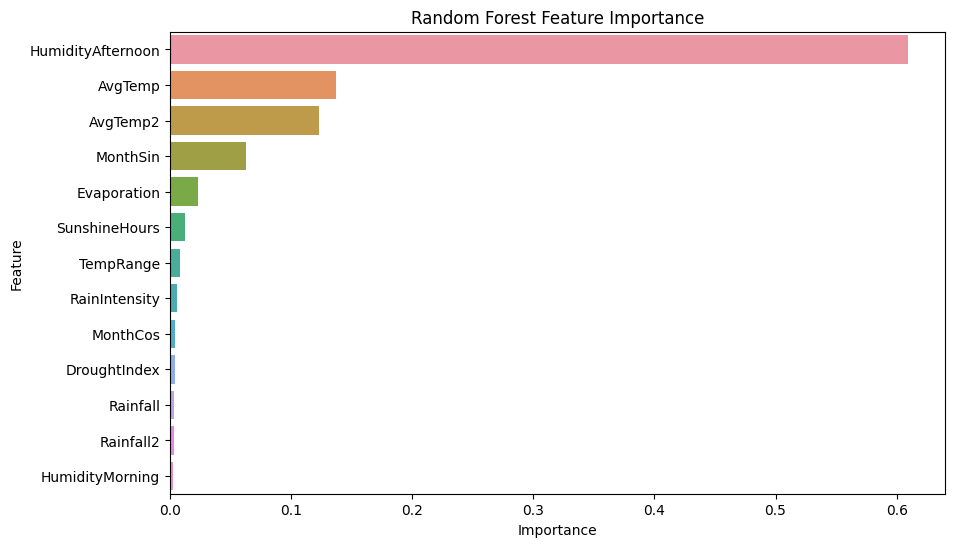

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")

plt.show()

---

# 17. Nonlinear Temperature Response

This section estimates the optimal temperature threshold.


In [78]:
beta1 = coef_df.loc[
    coef_df["Feature"] == "AvgTemp",
    "Coefficient"
].values[0]

beta2 = coef_df.loc[
    coef_df["Feature"] == "AvgTemp2",
    "Coefficient"
].values[0]

# Threshold temperature

optimal_temp = -beta1 / (2 * beta2)

print("Optimal Temperature:", optimal_temp)

Optimal Temperature: 0.5149401748658199


---

# 18. Temperature Response Curve


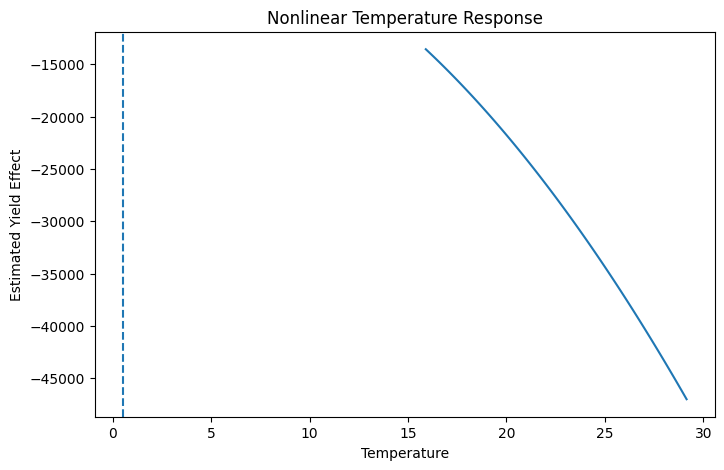

In [79]:
temp_range = np.linspace(
    df["AvgTemp"].min(),
    df["AvgTemp"].max(),
    100
)

response = (
    beta1 * temp_range +
    beta2 * (temp_range ** 2)
)

plt.figure(figsize=(8,5))

plt.plot(temp_range, response)

plt.axvline(
    x=optimal_temp,
    linestyle="--"
)

plt.title("Nonlinear Temperature Response")
plt.xlabel("Temperature")
plt.ylabel("Estimated Yield Effect")

plt.show()

---

# 19. Seasonal Tea Production Pattern

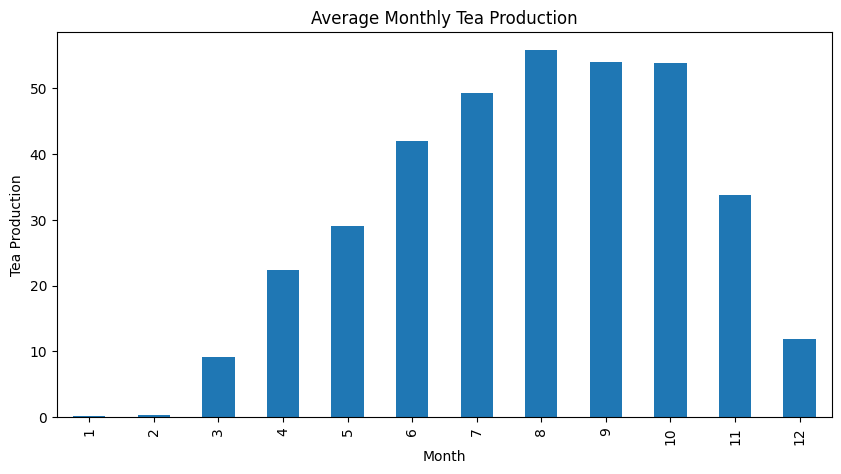

In [80]:
monthly_avg = df.groupby("Month")[
    "TeaProduction"
].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(kind="bar")

plt.title("Average Monthly Tea Production")
plt.ylabel("Tea Production")

plt.show()

---

# 20. Residual Diagnostics

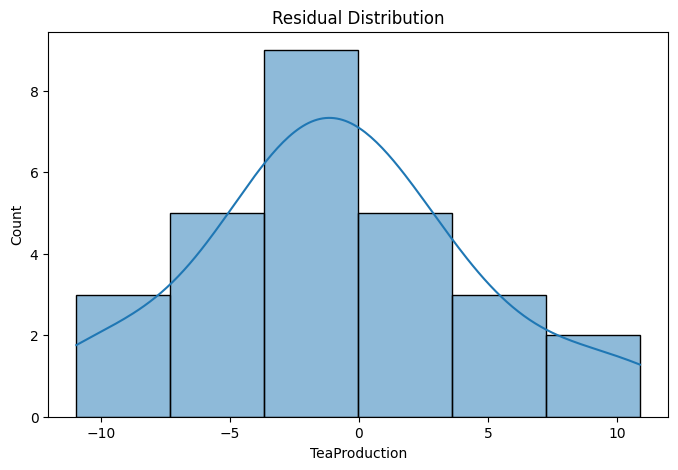

In [82]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

---

# 21. Predicted vs Actual

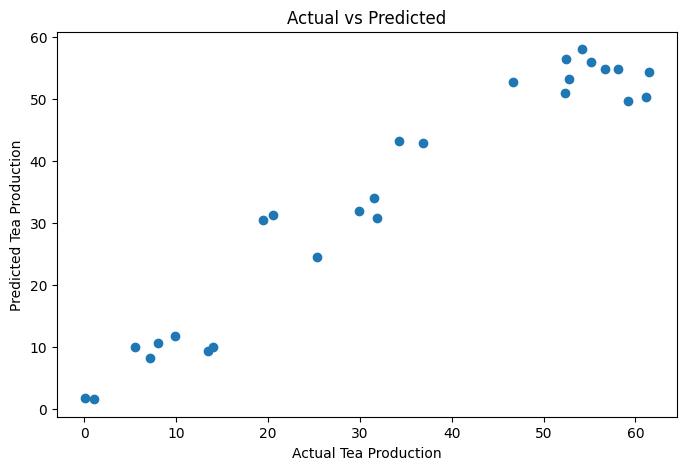

In [83]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Tea Production")
plt.ylabel("Predicted Tea Production")

plt.title("Actual vs Predicted")

plt.show()

---

# 22. Climate Stress Analysis

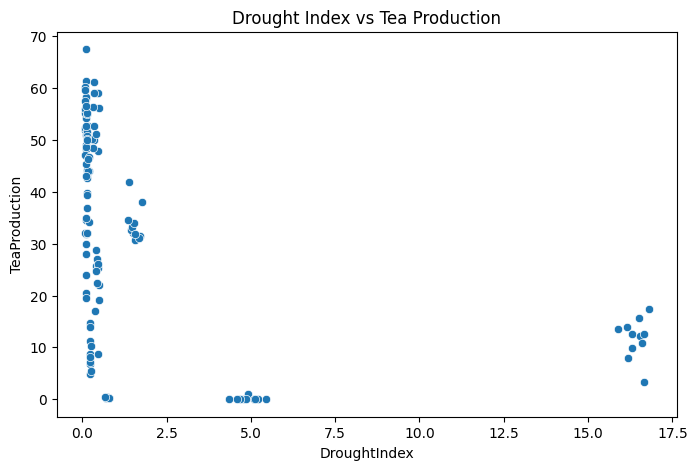

In [84]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["DroughtIndex"],
    y=df["TeaProduction"]
)

plt.title("Drought Index vs Tea Production")

plt.show()

---

# 23. Conclusion

The analysis demonstrates:

* Strong nonlinear climate effects.
* High sensitivity of tea productivity to sustained warming.
* Negative effects of rainfall intensity.
* Importance of humidity and sunshine.
* Potential climate vulnerability under future warming.

The workflow combines:

* econometrics,
* machine learning,
* climate analytics,
* agricultural modeling,
* nonlinear environmental analysis.